<div style="border: 2px solid #555; padding: 15px; border-radius: 10px;">
<h1>Project DermAI Assist : AI in the service of early Skin Cancer Detection</h1>
<div style="text-align: right; font-style: italic; color: #555;">
Assistance Tool for classifying skin lesions from images.
</div>
</div>

<h2 style="text-align: center; text-decoration: underline;">Data exploration</h2>


v1.0,
date : 2025/11/12,
Author : Arnauld

## Team members:
-Lesly
-Yuwani
-Arnauld
-Elie (leader)
-Pedro


## Data's Organization

- A file named “HAM10000_metadata.csv” containing the features and targets of our study.

- Two directories containing images related to the cases described in the CSV file.

## Load the data

In [1]:
import pandas as pd

# Path to your CSV file
file_path = "../raw_data/HAM10000_metadata.csv"

# Load the CSV into a Pandas DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows to check the data
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


<table style="margin-left:0; padding-left:0; border-collapse: collapse;">
  <tr><th>Column</th><th>Meaning</th></tr>
  <tr><td><code>lesion_id</code></td><td>Unique ID for each lesion (same lesion may have multiple images)</td></tr>
  <tr><td><code>image_id</code></td><td>Unique ID for the image file (corresponds to image filenames)</td></tr>
  <tr><td><code>dx</code></td><td>Diagnosis (e.g., <code>bkl</code>, <code>mel</code>, <code>nv</code>, etc.)</td></tr>
  <tr><td><code>dx_type</code></td><td>How the diagnosis was obtained (<code>histo</code> = histopathology, etc.)</td></tr>
  <tr><td><code>age</code></td><td>Patient age</td></tr>
  <tr><td><code>sex</code></td><td>Patient sex</td></tr>
  <tr><td><code>localization</code></td><td>Body location of the lesion</td></tr>
</table>





<div style="border: 2px solid #555; border-radius: 6px; padding: 8px 16px; width: fit-content; margin: 0 auto; text-align: center; background: none;">

<h3 style="margin: 0;">dx</h3>

</div>



In [2]:
print(df["dx"].unique())
print(df["dx"].value_counts())

['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


| Label | Meaning | Count | Percentage |
|:------|:---------|------:|-----------:|
| `nv`    | Melanocytic nevi | 6705 | 66.9 % |
| `mel`   | Melanoma | 1113 | 11.1 % |
| `bkl`   | Benign keratosis-like lesions | 1099 | 11.0 % |
| `bcc`   | Basal cell carcinoma | 514 | 5.1 % |
| `akiec` | Actinic keratoses / intraepithelial carcinoma | 327 | 3.3 % |
| `vasc`  | Vascular lesions | 142 | 1.4 % |
| `df`    | Dermatofibroma | 115 | 1.1 % |
| **Total** | — | **10 015** | **100 %** |






It's seem that field is hightly unbalanced

<div style="border: 2px solid #555; border-radius: 6px; padding: 8px 16px; width: fit-content; margin: 0 auto; text-align: center; background: none;">

<h3 style="margin: 0;">dx_type</h3>

</div>


In [3]:
print(df["dx_type"].unique())
print(df["dx_type"].value_counts())

['histo' 'consensus' 'confocal' 'follow_up']
dx_type
histo        5340
follow_up    3704
consensus     902
confocal       69
Name: count, dtype: int64


| Label | Meaning | Count | Percentage |
|:------|:---------|------:|-----------:|
| `histo` | Histopathology (biopsy confirmed) | 5340 | 53.3 % |
| `follow_up` | Follow-up examination | 3704 | 37.0 % |
| `consensus` | Expert consensus | 902 | 9.0 % |
| `confocal` | Confocal microscopy | 69 | 0.7 % |
| **Total** | — | **10 015** | **100 %** |


also unbalanced

<div style="border: 2px solid #555; border-radius: 6px; padding: 8px 16px; width: fit-content; margin: 0 auto; text-align: center; background: none;">

<h3 style="margin: 0;">age</h3>

</div>


In [4]:
print(df["age"].unique())
print(df["age"].value_counts())

[80. 75. 60. 70. 55. 85. 65. 40. 50. 45. 35.  0. 30. nan  5. 25. 20. 10.
 15.]
age
45.0    1299
50.0    1187
55.0    1009
40.0     985
60.0     803
70.0     756
35.0     753
65.0     731
75.0     618
30.0     464
80.0     404
85.0     290
25.0     247
20.0     169
5.0       86
15.0      77
10.0      41
0.0       39
Name: count, dtype: int64


<div style="border: 2px solid #555; border-radius: 8px; padding: 10px; margin-left:0; width: fit-content; background: none;">

| Age | Count | Percentage |
|:----|------:|-----------:|
| 45.0 | 1299 | 12.9 % |
| 50.0 | 1187 | 11.8 % |
| 55.0 | 1009 | 10.1 % |
| 40.0 | 985 | 9.8 % |
| 60.0 | 803 | 8.0 % |
| 70.0 | 756 | 7.5 % |
| 35.0 | 753 | 7.5 % |
| 65.0 | 731 | 7.3 % |
| 75.0 | 618 | 6.2 % |
| 30.0 | 464 | 4.6 % |
| 80.0 | 404 | 4.0 % |
| 85.0 | 290 | 2.9 % |
| 25.0 | 247 | 2.5 % |
| 20.0 | 169 | 1.7 % |
| 5.0  | 86  | 0.9 % |
| 15.0 | 77  | 0.8 % |
| 10.0 | 41  | 0.4 % |
| 0.0  | 39  | 0.4 % |
| **Total** | **10 038** | **100 %** |

</div>


we have more values than dx and dx_type (10039 vs 10015)

<div style="border: 2px solid #555; border-radius: 6px; padding: 8px 16px; width: fit-content; margin: 0 auto; text-align: center; background: none;">

<h3 style="margin: 0;">sex</h3>

</div>

In [5]:
print(df["sex"].unique())
print(df["sex"].value_counts())

['male' 'female' 'unknown']
sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64


| Sex | Count | Percentage |
|:------|------:|-----------:|
| `male` | 5406 | 54.0 % |
| `female` | 4552 | 45.4 % |
| `unknown` | 57 | 0.6 % |
| **Total** | **10 015** | **100 %** |


<div style="border: 2px solid #555; border-radius: 6px; padding: 8px 16px; width: fit-content; margin: 0 auto; text-align: center; background: none;">

<h3 style="margin: 0;">localization</h3>

</div>

In [6]:
print(df["localization"].unique())
print(df["localization"].value_counts())

['scalp' 'ear' 'face' 'back' 'trunk' 'chest' 'upper extremity' 'abdomen'
 'unknown' 'lower extremity' 'genital' 'neck' 'hand' 'foot' 'acral']
localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64


| Localization | Count | Percentage |
|:------------------|------:|-----------:|
| `back` | 2192 | 21.9 % |
| `lower extremity` | 2077 | 20.7 % |
| `trunk` | 1404 | 14.0 % |
| `upper extremity` | 1118 | 11.2 % |
| `abdomen` | 1022 | 10.2 % |
| `face` | 745 | 7.4 % |
| `chest` | 407 | 4.1 % |
| `foot` | 319 | 3.2 % |
| `unknown` | 234 | 2.3 % |
| `neck` | 168 | 1.7 % |
| `scalp` | 128 | 1.3 % |
| `hand` | 90 | 0.9 % |
| `ear` | 56 | 0.6 % |
| `genital` | 48 | 0.5 % |
| `acral` | 7 | 0.1 % |
| **Total** | **10 015** | **100 %** |


In [7]:
%matplotlib inline


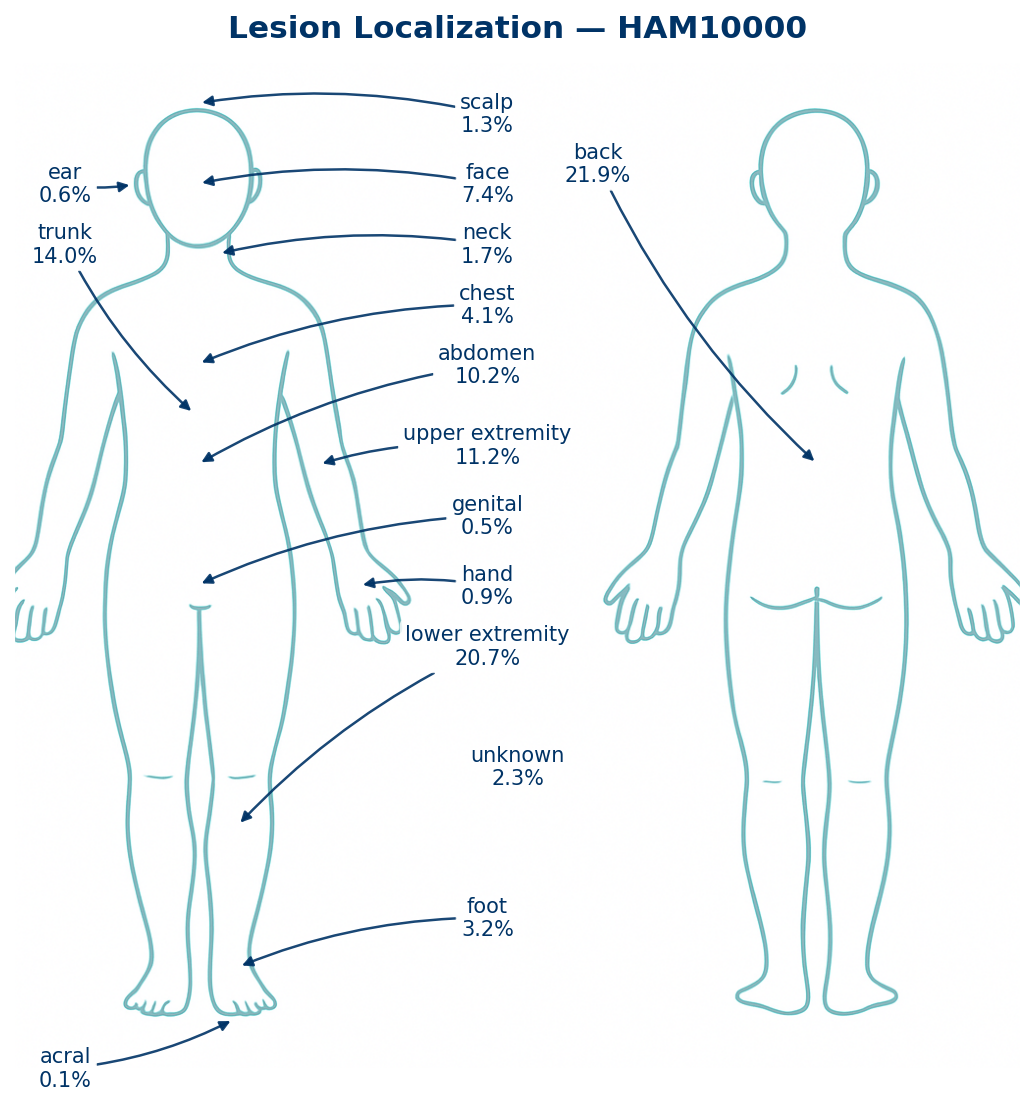

In [8]:
### BEWARE AT FILE  "A_2D_digital_illustration_displays_two_simplified_.png"

### RE-RUN WITH CAUTIOUS


import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# 1️⃣ Load dataset
csv_path = "../raw_data/HAM10000_metadata.csv"
df = pd.read_csv(csv_path)

# 2️⃣ Compute localization percentages
counts = df["localization"].value_counts()
total = counts.sum()
loc_pct = (counts / total * 100).round(1).to_dict()

# 3️⃣ Load silhouette PNG (clean version)
img_path = "A_2D_digital_illustration_displays_two_simplified_.png"
if not os.path.exists(img_path):
    raise FileNotFoundError(img_path)
img = mpimg.imread(img_path)

# 4️⃣ Improved positions (anchor = where arrow points, text = where label appears)
positions = {
    # --- FRONT (left figure) ---
    "scalp":             {"anchor": (0.18, 0.96), "text": (0.47, 0.95)},
    "face":              {"anchor": (0.18, 0.88), "text": (0.47, 0.88)},
    "ear":               {"anchor": (0.12, 0.88), "text": (0.05, 0.88)},  # higher and more left
    "neck":              {"anchor": (0.20, 0.81), "text": (0.47, 0.82)},
    "chest":             {"anchor": (0.18, 0.70), "text": (0.47, 0.76)},
    "abdomen":           {"anchor": (0.18, 0.60), "text": (0.47, 0.70)},
    "genital":           {"anchor": (0.18, 0.48), "text": (0.47, 0.55)},
    "upper extremity":   {"anchor": (0.30, 0.60), "text": (0.47, 0.62)},
    "hand":              {"anchor": (0.34, 0.48), "text": (0.47, 0.48)},
    "lower extremity":   {"anchor": (0.22, 0.24), "text": (0.47, 0.42)},
    "foot":              {"anchor": (0.22, 0.1), "text": (0.47, 0.15)},
    "acral":             {"anchor": (0.22, 0.05), "text": (0.05, 0.00)},

    # --- BACK (right figure) ---
    "back":              {"anchor": (0.80, 0.60), "text": (0.58, 0.90)},
    "trunk":             {"anchor": (0.18, 0.65), "text": (0.05, 0.82)},
    "unknown":           {"anchor": (0.50, 0.30), "text": (0.50, 0.30)},
}

# 5️⃣ Plot with longer arrows
fig, ax = plt.subplots(figsize=(7, 10), dpi=150)
ax.imshow(img)
ax.axis("off")

ax.text(0.5, 1.02, "Lesion Localization — HAM10000",
        ha="center", va="bottom", transform=ax.transAxes,
        fontsize=15, fontweight="bold", color="#003366")

# Draw annotations with longer arrows
for loc, pct in loc_pct.items():
    if loc in positions:
        p = positions[loc]
        ax.annotate(
            f"{loc}\n{pct}%",
            xy=p["anchor"], xycoords="axes fraction",
            xytext=p["text"], textcoords="axes fraction",
            fontsize=10, ha="center", va="center", color="#003366",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.8),
            arrowprops=dict(
                arrowstyle="-|>", color="#003366", lw=1.2,
                shrinkA=0, shrinkB=3, connectionstyle="arc3,rad=0.1", alpha=0.9
            )
        )
    else:
        print(f"⚠️ Skipping '{loc}': no position defined")

plt.tight_layout()
plt.show()


There are some inaccuracies between trunk, chest, and abdomen.
Trunk = chest + abdomen

## Pre-Cleaning vérification

In [9]:
df.isna().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [10]:
df[df.isna().any(axis=1)].head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
968,HAM_0001186,ISIC_0033391,bkl,consensus,NaN,unknown,unknown
969,HAM_0002660,ISIC_0033750,bkl,consensus,NaN,unknown,unknown
970,HAM_0000372,ISIC_0033685,bkl,consensus,NaN,unknown,unknown
971,HAM_0000948,ISIC_0033631,bkl,consensus,NaN,unknown,unknown
972,HAM_0000983,ISIC_0033490,bkl,consensus,NaN,unknown,unknown


We note that values at NAN may imply others at 'Unknown'.
see further:

In [11]:
(df.isna() | (df == 'unknown')).sum()

lesion_id         0
image_id          0
dx                0
dx_type           0
age              57
sex              57
localization    234
dtype: int64

In [12]:
df_unknown_loc = df[df['localization'] == 'unknown']
df_unknown_loc.shape

(234, 7)

In [13]:
df_unknown_loc.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
50,HAM_0003670,ISIC_0030105,bkl,histo,80.0,female,unknown
56,HAM_0003569,ISIC_0027960,bkl,histo,75.0,male,unknown
57,HAM_0003569,ISIC_0026955,bkl,histo,75.0,male,unknown
140,HAM_0002774,ISIC_0029683,bkl,histo,65.0,male,unknown
461,HAM_0005527,ISIC_0031819,bkl,histo,50.0,male,unknown


we notice another value that cannot be guessed: 'unknown'

In [16]:
# Count total occurrences of each dx in the whole dataset
total_dx = df['dx'].value_counts()

# Count dx only where localization is 'unknown'
unknown_dx = df[df['localization'] == 'unknown']['dx'].value_counts()

# Combine both into a single DataFrame
dx_analysis = pd.DataFrame({
    'total_dx': total_dx,
    'unknown_dx': unknown_dx
}).fillna(0)

# Add percentage columns
# %_unknown_within_dx → proportion of unknown localization within each dx
# %_within_unknown_total → proportion of each dx among all unknown localizations
dx_analysis['%_unknown_within_dx'] = (dx_analysis['unknown_dx'] / dx_analysis['total_dx']) * 100
dx_analysis['%_within_unknown_total'] = (dx_analysis['unknown_dx'] / dx_analysis['unknown_dx'].sum()) * 100

# Sort for readability (highest % of missing localizations first)
dx_analysis = dx_analysis.sort_values('%_unknown_within_dx', ascending=False)

dx_analysis


,total_dx,unknown_dx,%_unknown_within_dx,%_within_unknown_total
dx,,,,
nv,6705,196.0,2.923192,83.760684
bkl,1099,23.0,2.092812,9.829060
bcc,514,5.0,0.972763,2.136752
mel,1113,10.0,0.898473,4.273504
akiec,327,0.0,0.000000,0.000000
df,115,0.0,0.000000,0.000000
vasc,142,0.0,0.000000,0.000000


### 🧾 Meaning of columns in `dx_analysis`

| **Column name** | **Description** | **Example interpretation** |
|------------------|-----------------|-----------------------------|
| `total_dx` | Total number of samples for each diagnosis (`dx`) in the whole dataset. | If `bcc = 20`, there are **20 total samples** labeled as *basal cell carcinoma*. |
| `unknown_dx` | Number of samples for that diagnosis where `localization == 'unknown'`. | If `bcc = 19`, then **19 of those 20 bcc samples** have a missing localization. |
| `%_unknown_within_dx` | Percentage of missing localizations **within that specific diagnosis**.<br>Formula → `(unknown_dx / total_dx) * 100` | If `bcc = 95%`, then **95% of all bcc samples** are missing localization info. |
| `%_within_unknown_total` | Percentage of that diagnosis **within all samples with `localization == 'unknown'`**.<br>Formula → `(unknown_dx / sum(unknown_dx)) * 100` | If `bcc = 2.13%`, then *bcc* represents **2.13% of all 234 “unknown” cases**. |


The lines affected (by dx value) do not exceed 3%. It might be wise to delete them.

## Appendix

Dictionaries for lesions and their diagnosis

In [ ]:
# Mapping for diagnosis labels (dx)
lesion_labels = {
    "akiec": "Actinic keratoses / intraepithelial carcinoma",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions"
}

# Mapping for diagnosis source (dx_type)
diag_sources = {
    "histo": "Histopathology (biopsy confirmed)",
    "follow_up": "Follow-up examination",
    "consensus": "Expert consensus",
    "confocal": "Confocal microscopy"
}